# Mask R-CNN — Patient-Level Test Evaluation

Patient-level test set evaluation of the Mask R-CNN baseline.


## Quantitative Results


# Mask R-CNN Test Tables Fixed

In [1]:
from pathlib import Path

import pandas as pd
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score

PRED_ROOT = Path("models2/maskrcnn/pred2")
N_FOLDS = 5


Evaluation libraries loaded.


In [2]:
seg_rows = []
cls_rows = []

for fold in range(1, N_FOLDS + 1):
    fold_dir = PRED_ROOT / f"fold_{fold}"
    seg_df = pd.read_csv(fold_dir / "kesit_duzeyi_sonuclar.csv")
    cls_df = pd.read_csv(fold_dir / "patient_level_results.csv")

    seg_rows.append({
        "Fold": f"Fold {fold}",
        "Dice Score": round(seg_df["seg_dice"].mean() * 100, 2),
        "IoU": round(seg_df["seg_jaccard"].mean() * 100, 2),
        "Pixel Acc.": round(seg_df["seg_piksel_dogruluk"].mean() * 100, 2),
    })

    y_true = cls_df["y_true_bin"].astype(int)
    y_pred = cls_df["pred_mean"].astype(int)
    y_score = cls_df["p_mean"].astype(float)
    cls_rows.append({
        "Fold": f"Fold {fold}",
        "Accuracy": round((y_true == y_pred).mean() * 100, 2),
        "F1 Score": round(f1_score(y_true, y_pred, zero_division=0) * 100, 2),
        "ROC-AUC": round(roc_auc_score(y_true, y_score) * 100, 2),
        "PR-AUC": round(average_precision_score(y_true, y_score) * 100, 2),
    })

seg_table = pd.DataFrame(seg_rows)
cls_table = pd.DataFrame(cls_rows)

seg_numeric = seg_table[["Dice Score", "IoU", "Pixel Acc."]]
cls_numeric = cls_table[["Accuracy", "F1 Score", "ROC-AUC", "PR-AUC"]]

seg_table.loc[len(seg_table)] = {
    "Fold": "Mean±Std",
    "Dice Score": f"{seg_numeric['Dice Score'].mean():.2f} ± {seg_numeric['Dice Score'].std(ddof=1):.2f}",
    "IoU": f"{seg_numeric['IoU'].mean():.2f} ± {seg_numeric['IoU'].std(ddof=1):.2f}",
    "Pixel Acc.": f"{seg_numeric['Pixel Acc.'].mean():.2f} ± {seg_numeric['Pixel Acc.'].std(ddof=1):.2f}",
}

cls_table.loc[len(cls_table)] = {
    "Fold": "Mean±Std",
    "Accuracy": f"{cls_numeric['Accuracy'].mean():.2f} ± {cls_numeric['Accuracy'].std(ddof=1):.2f}",
    "F1 Score": f"{cls_numeric['F1 Score'].mean():.2f} ± {cls_numeric['F1 Score'].std(ddof=1):.2f}",
    "ROC-AUC": f"{cls_numeric['ROC-AUC'].mean():.2f} ± {cls_numeric['ROC-AUC'].std(ddof=1):.2f}",
    "PR-AUC": f"{cls_numeric['PR-AUC'].mean():.2f} ± {cls_numeric['PR-AUC'].std(ddof=1):.2f}",
}

seg_out = PRED_ROOT / "test_segmentation_table_fixed.csv"
cls_out = PRED_ROOT / "test_classification_table_fixed.csv"
seg_table.to_csv(seg_out, index=False)
cls_table.to_csv(cls_out, index=False)

print("Kaydedildi:", seg_out)
print("Kaydedildi:", cls_out)


Kaydedildi: models2/maskrcnn/pred2/test_segmentation_table_fixed.csv
Kaydedildi: models2/maskrcnn/pred2/test_classification_table_fixed.csv


In [3]:
print("Tablo 4 - Test segmentasyon")
display(seg_table)

print("Tablo 5 - Test hasta duzeyi siniflandirma")
display(cls_table)


Tablo 4 - Test segmentasyon


,Fold,Dice Score,IoU,Pixel Acc.
0,Fold 1,76.23,65.96,99.23
1,Fold 2,71.67,61.45,98.74
2,Fold 3,78.47,67.53,99.18
3,Fold 4,73.4,63.69,99.26
4,Fold 5,76.8,66.4,98.43
5,Mean±Std,75.31 ± 2.74,65.01 ± 2.43,98.97 ± 0.37


Tablo 5 - Test hasta duzeyi siniflandirma


,Fold,Accuracy,F1 Score,ROC-AUC,PR-AUC
0,Fold 1,84.62,83.33,82.5,65.95
1,Fold 2,92.31,92.31,97.62,98.21
2,Fold 3,76.92,76.92,88.1,85.56
3,Fold 4,100.0,100.0,100.0,100.0
4,Fold 5,84.62,80.0,95.0,92.67
5,Mean±Std,87.69 ± 8.77,86.51 ± 9.49,92.64 ± 7.21,88.48 ± 13.79


## Fold-wise Dice Boxplots


# Mask R-CNN Test-Only Boxplots

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

PRED_ROOT = Path("models2/maskrcnn/pred2")
N_BOOT = 2000
RNG_SEED = 42


Visualization libraries loaded.


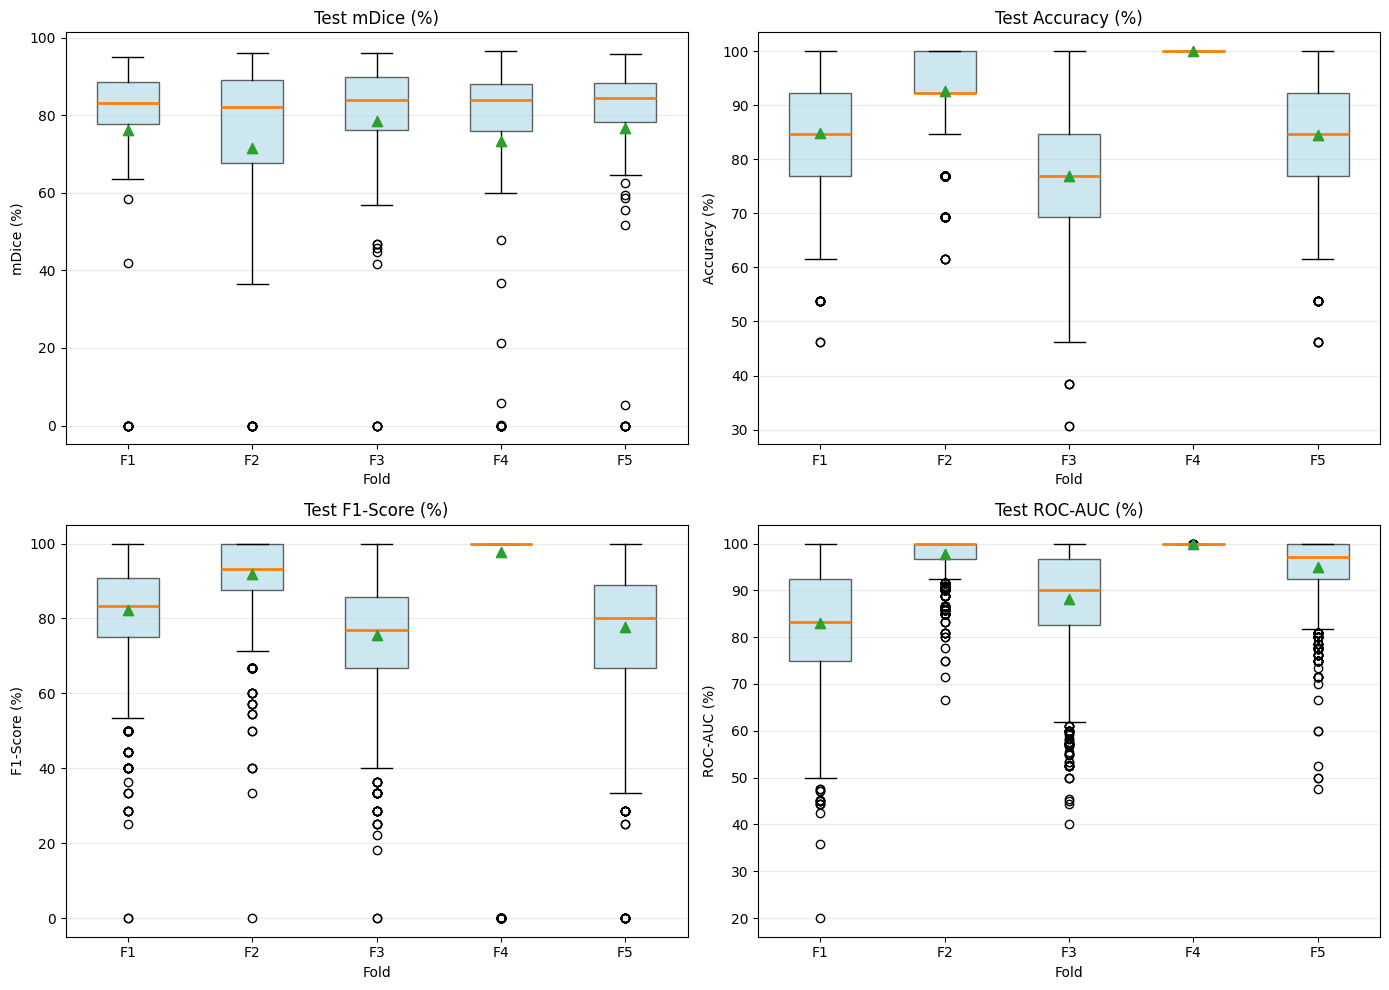

Kaydedildi: models2/maskrcnn/pred2/per_fold_boxplots_fixed.png


In [2]:
def pick_col(df, *candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"Missing columns: {candidates}")

def read_csv_by_names(folder, names):
    for name in names:
        path = folder / name
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError(f"No matching CSV under {folder}: {names}")

def bootstrap_patient_metrics(df, truth_col, pred_col, score_col, n_boot=N_BOOT, seed=RNG_SEED):
    truth = pd.to_numeric(df[truth_col], errors="coerce").to_numpy(dtype=float)
    pred = pd.to_numeric(df[pred_col], errors="coerce").to_numpy(dtype=float)
    score = pd.to_numeric(df[score_col], errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(truth) & np.isfinite(pred) & np.isfinite(score)
    y_true = truth[mask].astype(int)
    y_pred = pred[mask].astype(int)
    y_score = score[mask].astype(float)
    rng = np.random.default_rng(seed)
    accs, f1s, rocs = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), size=len(y_true))
        yt = y_true[idx]
        yp = y_pred[idx]
        ys = y_score[idx]
        accs.append(accuracy_score(yt, yp) * 100.0)
        f1s.append(f1_score(yt, yp, zero_division=0) * 100.0)
        if np.unique(yt).size == 2:
            rocs.append(roc_auc_score(yt, ys) * 100.0)
    return np.asarray(accs), np.asarray(f1s), np.asarray(rocs)

def styled_boxplot(ax, data_by_fold, title, ylabel, fold_labels):
    bp = ax.boxplot(data_by_fold, tick_labels=fold_labels, patch_artist=True, showfliers=True, widths=0.5)
    for patch in bp["boxes"]:
        patch.set_facecolor("#add8e6")
        patch.set_alpha(0.6)
        patch.set_edgecolor("black")
    for med in bp["medians"]:
        med.set_color("#ff7f0e")
        med.set_linewidth(2)
    for item in bp["whiskers"] + bp["caps"]:
        item.set_color("black")
    means = [float(np.mean(x)) if len(x) else np.nan for x in data_by_fold]
    ax.scatter(np.arange(1, len(means) + 1), means, marker="^", s=55, color="#2ca02c", zorder=3)
    ax.set_title(title)
    ax.set_xlabel("Fold")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)

fold_labels, dice_data, acc_data, f1_data, roc_data = [], [], [], [], []

for fold in range(1, 6):
    fold_dir = PRED_ROOT / f"fold_{fold}"
    if not fold_dir.exists():
        continue
    slice_df = read_csv_by_names(fold_dir, ["slice_level_results.csv", "kesit_duzeyi_sonuclar.csv"])
    patient_df = read_csv_by_names(fold_dir, ["patient_level_results.csv", "hasta_duzeyi_sonuclar.csv"])
    dice_col = pick_col(slice_df, "seg_dice")
    truth_col = pick_col(patient_df, "y_true_bin", "gt_sinif_bin")
    pred_col = pick_col(patient_df, "pred_mean", "tahmin_ortalama")
    score_col = pick_col(patient_df, "p_mean", "p_ortalama")
    dice = pd.to_numeric(slice_df[dice_col], errors="coerce").dropna().to_numpy(dtype=float) * 100.0
    accs, f1s, rocs = bootstrap_patient_metrics(patient_df, truth_col, pred_col, score_col)
    fold_labels.append(f"F{fold}")
    dice_data.append(dice)
    acc_data.append(accs)
    f1_data.append(f1s)
    roc_data.append(rocs)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
styled_boxplot(axes[0, 0], dice_data, "Test mDice (%)", "mDice (%)", fold_labels)
styled_boxplot(axes[0, 1], acc_data, "Test Accuracy (%)", "Accuracy (%)", fold_labels)
styled_boxplot(axes[1, 0], f1_data, "Test F1-Score (%)", "F1-Score (%)", fold_labels)
styled_boxplot(axes[1, 1], roc_data, "Test ROC-AUC (%)", "ROC-AUC (%)", fold_labels)
plt.tight_layout()
out_png = PRED_ROOT / "per_fold_boxplots_fixed.png"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.show()
print("Kaydedildi:", out_png)


---

## Per-Fold Confusion Matrices (Figure 6B)

Patient-level confusion matrices for each of the 5 outer folds, plus the aggregated combined matrix.


FOLD_1: 13 patients | CM=[[6, 2], [0, 5]] | Acc=0.8462
FOLD_2: 13 patients | CM=[[6, 0], [1, 6]] | Acc=0.9231
FOLD_3: 13 patients | CM=[[5, 2], [1, 5]] | Acc=0.7692
FOLD_4: 13 patients | CM=[[10, 0], [0, 3]] | Acc=1.0000
FOLD_5: 13 patients | CM=[[7, 1], [1, 4]] | Acc=0.8462

Combined CM: [[34, 5], [3, 23]]
Overall Accuracy: 0.8769


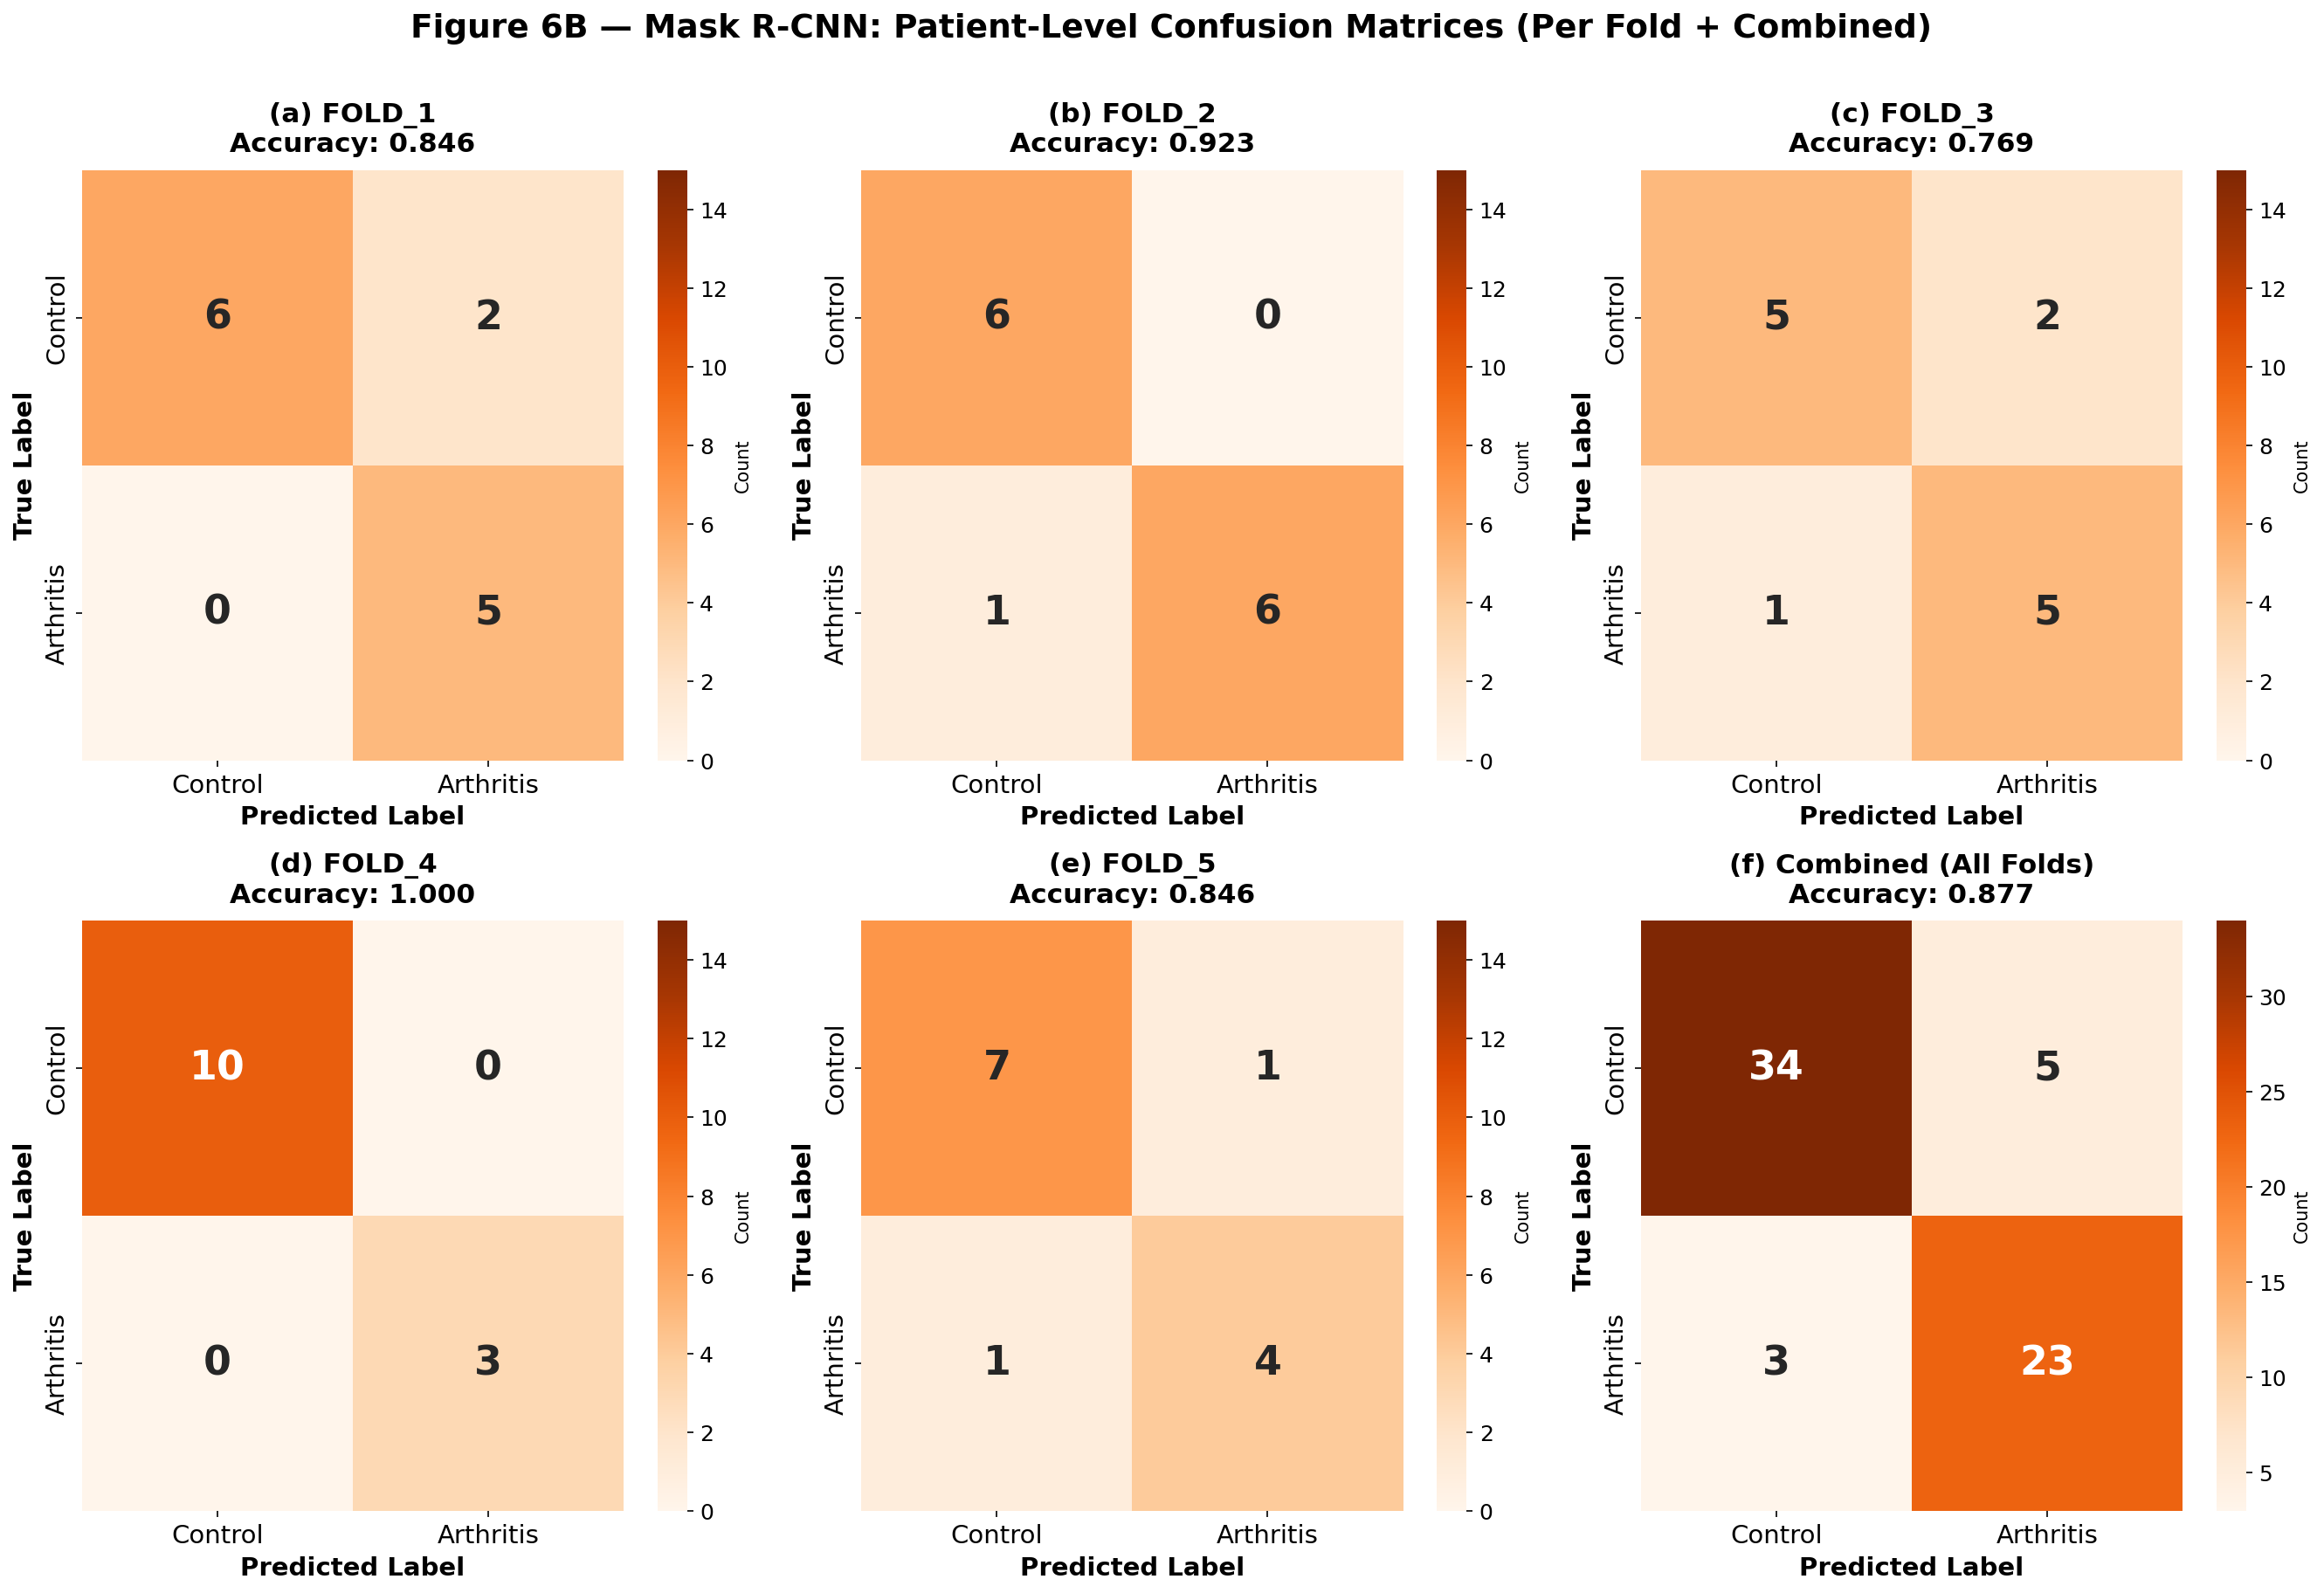

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix

PRED_ROOT = Path("models2/maskrcnn/pred2")
FOLDS = ["fold_1", "fold_2", "fold_3", "fold_4", "fold_5"]
class_names = ["Control", "Arthritis"]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()
fold_labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]
all_y_true, all_y_pred = [], []

for idx, fold in enumerate(FOLDS):
    df = pd.read_csv(PRED_ROOT / fold / "patient_level_results.csv")
    y_true = df["y_true_bin"].values
    y_pred = df["pred_majority"].values
    all_y_true.extend(y_true.tolist())
    all_y_pred.extend(y_pred.tolist())
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    ax = axes[idx]
    accuracy = np.trace(cm) / cm.sum()
    hm = sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                     xticklabels=class_names, yticklabels=class_names,
                     cbar_kws={"label": "Count"}, ax=ax,
                     annot_kws={"size": 22, "weight": "bold"}, vmin=0, vmax=15)
    ax.set_xlabel("Predicted Label", fontsize=14, fontweight="bold")
    ax.set_ylabel("True Label", fontsize=14, fontweight="bold")
    ax.set_title(f"{fold_labels[idx]} FOLD_{idx+1}\nAccuracy: {accuracy:.3f}",
                 fontsize=15, fontweight="bold", pad=10)
    ax.tick_params(labelsize=13)
    hm.collections[0].colorbar.ax.tick_params(labelsize=12)
    print(f"FOLD_{idx+1}: {len(df)} patients | CM={cm.tolist()} | Acc={accuracy:.4f}")

cm_combined = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1])
acc_c = np.trace(cm_combined) / cm_combined.sum()
ax6 = axes[5]
hm2 = sns.heatmap(cm_combined, annot=True, fmt="d", cmap="Oranges",
                  xticklabels=class_names, yticklabels=class_names,
                  cbar_kws={"label": "Count"}, ax=ax6,
                  annot_kws={"size": 22, "weight": "bold"})
ax6.set_xlabel("Predicted Label", fontsize=14, fontweight="bold")
ax6.set_ylabel("True Label", fontsize=14, fontweight="bold")
ax6.set_title(f"(f) Combined (All Folds)\nAccuracy: {acc_c:.3f}",
              fontsize=15, fontweight="bold", pad=10)
ax6.tick_params(labelsize=13)
hm2.collections[0].colorbar.ax.tick_params(labelsize=12)

fig.suptitle("Figure 6B — Mask R-CNN: Patient-Level Confusion Matrices (Per Fold + Combined)",
             fontsize=18, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nCombined CM: {cm_combined.tolist()}")
print(f"Overall Accuracy: {acc_c:.4f}")